**NLP For Finance**

**## 1. Setup & Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

**## 2. Fetching JPM News Sentiment (Alpha Vantage API)**

In [ ]:
api_key = "YOUR KEY"

In [3]:
url = 'https://www.alphavantage.co/query'

In [4]:
params = {
    'function': 'NEWS_SENTIMENT',
    'tickers': 'JPM',
    'time_from': '20240101T0000',
    'time_to': '20240401T0000',
    'limit': 50,
    'apikey': api_key
}

response = requests.get(url, params=params)
data = response.json()
print(data.keys())

dict_keys(['items', 'sentiment_score_definition', 'relevance_score_definition', 'feed'])


In [5]:
print(data['items'])
print(data['feed'][0])

50
{'title': 'Banc of California: Post-Merger Optimism', 'url': 'https://labusinessjournal.com/special-reports/banc-of-california-post-merger-optimism/', 'time_published': '20240401T000000', 'authors': ['James Brock'], 'summary': "Banc of California CEO Jared Wolff discusses the successful and rapid integration following its 2023 merger with PacWest, which created a $38 billion entity. Wolff highlights the bank's strategy in bridging capital for portfolio companies and managing its commercial real estate exposure, particularly to office space. He also shares his optimistic outlook on the Southern California economy's resilience despite recent regional banking industry shifts and transaction slowdowns.", 'banner_image': None, 'source': 'Los Angeles Business Journal', 'category_within_source': 'General', 'source_domain': 'Los Angeles Business Journal', 'topics': [{'topic': 'mergers_and_acquisitions', 'relevance_score': '1.000000'}, {'topic': 'finance', 'relevance_score': '1.000000'}, {'t

**## 3. Extracting Relevance-Weighted Sentiment**

In [6]:
import json
print(json.dumps(data['feed'][0], indent=2))

{
  "title": "Banc of California: Post-Merger Optimism",
  "url": "https://labusinessjournal.com/special-reports/banc-of-california-post-merger-optimism/",
  "time_published": "20240401T000000",
  "authors": [
    "James Brock"
  ],
  "summary": "Banc of California CEO Jared Wolff discusses the successful and rapid integration following its 2023 merger with PacWest, which created a $38 billion entity. Wolff highlights the bank's strategy in bridging capital for portfolio companies and managing its commercial real estate exposure, particularly to office space. He also shares his optimistic outlook on the Southern California economy's resilience despite recent regional banking industry shifts and transaction slowdowns.",
  "banner_image": null,
  "source": "Los Angeles Business Journal",
  "category_within_source": "General",
  "source_domain": "Los Angeles Business Journal",
  "topics": [
    {
      "topic": "mergers_and_acquisitions",
      "relevance_score": "1.000000"
    },
    {
 

In [7]:
records = []

for article in data['feed']:
    date = article['time_published'][:8]
    for ticker_info in article['ticker_sentiment']:
        if ticker_info['ticker'] == 'JPM':
            relevance = float(ticker_info['relevance_score'])
            sentiment = float(ticker_info['ticker_sentiment_score'])
            weighted = sentiment * relevance
            records.append({'date': date, 'weighted_sentiment': weighted})

sentiment_df = pd.DataFrame(records)
print(sentiment_df.shape)
print(sentiment_df.head())

(50, 2)
       date  weighted_sentiment
0  20240401           -0.069458
1  20240329            0.247672
2  20240328            0.071201
3  20240328            0.146029
4  20240328            0.003532


In [8]:
params_old = {
    'function': 'NEWS_SENTIMENT',
    'tickers': 'JPM',
    'time_from': '20180101T0000',
    'time_to': '20180401T0000',
    'limit': 50,
    'apikey': api_key
}

response_old = requests.get(url, params=params_old)
data_old = response_old.json()
print(data_old.get('items', 'no items key'))
print(data_old.get('feed', 'no feed key')[:1] if 'feed' in data_old else data_old)

no items key
{'Information': 'Thank you for using Alpha Vantage! Please consider spreading out your free API requests more sparingly (1 request per second). You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to lift the free key rate limit (25 requests per day), raise the per-second burst limit, and instantly unlock all premium endpoints'}


In [9]:
print(json.dumps(data['feed'][0], indent=2))

{
  "title": "Banc of California: Post-Merger Optimism",
  "url": "https://labusinessjournal.com/special-reports/banc-of-california-post-merger-optimism/",
  "time_published": "20240401T000000",
  "authors": [
    "James Brock"
  ],
  "summary": "Banc of California CEO Jared Wolff discusses the successful and rapid integration following its 2023 merger with PacWest, which created a $38 billion entity. Wolff highlights the bank's strategy in bridging capital for portfolio companies and managing its commercial real estate exposure, particularly to office space. He also shares his optimistic outlook on the Southern California economy's resilience despite recent regional banking industry shifts and transaction slowdowns.",
  "banner_image": null,
  "source": "Los Angeles Business Journal",
  "category_within_source": "General",
  "source_domain": "Los Angeles Business Journal",
  "topics": [
    {
      "topic": "mergers_and_acquisitions",
      "relevance_score": "1.000000"
    },
    {
 

**## 4. Full Historical Pull (2018-2024, 14 chunks)**

In [10]:
date_ranges = [
    ('20180101T0000', '20180701T0000'),
    ('20180701T0000', '20190101T0000'),
    ('20190101T0000', '20190701T0000'),
    ('20190701T0000', '20200101T0000'),
    ('20200101T0000', '20200701T0000'),
    ('20200701T0000', '20210101T0000'),
    ('20210101T0000', '20210701T0000'),
    ('20210701T0000', '20220101T0000'),
    ('20220101T0000', '20220701T0000'),
    ('20220701T0000', '20230101T0000'),
    ('20230101T0000', '20230701T0000'),
    ('20230701T0000', '20240101T0000'),
    ('20240101T0000', '20240701T0000'),
    ('20240701T0000', '2025101T0000'),


]

In [11]:
import time

all_records = []

for start, end in date_ranges:
    params = {
        'function': 'NEWS_SENTIMENT',
        'tickers': 'JPM',
        'time_from': start,
        'time_to': end,
        'limit': 1000,
        'apikey': api_key
    }
    response = requests.get(url, params=params)
    data = response.json()

    if 'feed' not in data:
        print(f"No feed for {start} to {end}")
        continue

    for article in data['feed']:
        date = article['time_published'][:8]
        for ticker_info in article['ticker_sentiment']:
            if ticker_info['ticker'] == 'JPM':
                relevance = float(ticker_info['relevance_score'])
                sentiment = float(ticker_info['ticker_sentiment_score'])
                weighted = sentiment * relevance
                all_records.append({'date': date, 'weighted_sentiment': weighted})

    time.sleep(15)
    print(f"Done: {start} to {end}, total records so far: {len(all_records)}")

No feed for 20180101T0000 to 20180701T0000
No feed for 20180701T0000 to 20190101T0000
No feed for 20190101T0000 to 20190701T0000
No feed for 20190701T0000 to 20200101T0000
No feed for 20200101T0000 to 20200701T0000
Done: 20200701T0000 to 20210101T0000, total records so far: 466
Done: 20210101T0000 to 20210701T0000, total records so far: 1064
Done: 20210701T0000 to 20220101T0000, total records so far: 1618
Done: 20220101T0000 to 20220701T0000, total records so far: 2136
Done: 20220701T0000 to 20230101T0000, total records so far: 2696
Done: 20230101T0000 to 20230701T0000, total records so far: 3118
Done: 20230701T0000 to 20240101T0000, total records so far: 3489
Done: 20240101T0000 to 20240701T0000, total records so far: 3964
Done: 20240701T0000 to 2025101T0000, total records so far: 4965


**## 5. Daily Sentiment Aggregation**

In [12]:
sentiment_df = pd.DataFrame(all_records)
sentiment_df.to_csv('jpm_news_sentiment_raw.csv', index=False)
print(sentiment_df.shape)
print(sentiment_df.head())

(4965, 2)
       date  weighted_sentiment
0  20210101            0.177882
1  20210101            0.202540
2  20210101            0.090300
3  20210101            0.260128
4  20201231            0.401830


In [13]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4965 entries, 0 to 4964
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                4965 non-null   object 
 1   weighted_sentiment  4965 non-null   float64
dtypes: float64(1), object(1)
memory usage: 77.7+ KB


In [14]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], errors='coerce')

In [15]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4965 entries, 0 to 4964
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                4965 non-null   datetime64[ns]
 1   weighted_sentiment  4965 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 77.7 KB


In [16]:
daily_sentiment = sentiment_df.groupby('date')['weighted_sentiment'].mean().reset_index()
daily_sentiment.shape

(1266, 2)

In [17]:
print(daily_sentiment.head())

        date  weighted_sentiment
0 2020-07-01            0.269930
1 2020-07-02            0.127624
2 2020-07-03            0.085030
3 2020-07-04            0.235015
4 2020-07-07            0.301269


**## 6. Price Data Pipeline (JPM + S&P 500 Features)**

In [18]:
import yfinance as yf

In [19]:
jpmc = yf.download(['JPM'],start = '2010-01-1',end='2025-01-01')
sp500 = yf.download(['^GSPC'],start = '2010-01-1',end='2025-01-01')

/tmp/ipykernel_573/4128732890.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  jpmc = yf.download(['JPM'],start = '2010-01-1',end='2025-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_573/4128732890.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download(['^GSPC'],start = '2010-01-1',end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


In [20]:
jpmc.isnull().sum().sum()

np.int64(0)

In [21]:
jpmc.duplicated().sum()

np.int64(0)

In [22]:
jpmc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3774 entries, 2010-01-04 to 2024-12-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, JPM)   3774 non-null   float64
 1   (High, JPM)    3774 non-null   float64
 2   (Low, JPM)     3774 non-null   float64
 3   (Open, JPM)    3774 non-null   float64
 4   (Volume, JPM)  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB


In [23]:
jpmc['returns'] = jpmc['Close']['JPM'].pct_change(fill_method=None)

In [24]:
#volume ratio
volume = jpmc['Volume']['JPM']
jpmc['volume ratio'] = (volume/ volume.rolling(window=20).mean()).shift(1)

In [25]:
#20-day rolling return
jpmc['20-day rolling return'] = jpmc['returns'].rolling(window=20).mean().shift(1)

In [26]:
delta = jpmc['Close']['JPM'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
RSI = 100 - (100 / (1 + gain/loss))
jpmc['RSI'] = RSI.shift(1)

In [27]:
sp500['SP500 returns'] = sp500['Close']['^GSPC'].pct_change(fill_method=None)

In [28]:
jpmc_clean = pd.DataFrame({
    "returns": jpmc['returns'],
    "Volume Ratio": jpmc['volume ratio'],
    "Rolling Returns": jpmc['20-day rolling return'],
    "RSI": jpmc['RSI']
})

In [29]:
jpmc_clean['target'] = (jpmc_clean['returns'] > 0).astype(int).shift(-1)

In [30]:
jpmc_clean['SP500 Returns'] = sp500['SP500 returns']

**## 7. Merging Sentiment with Price Features**

In [31]:
jpmc_with_sentiment = jpmc_clean.merge(daily_sentiment, left_index=True, right_on='date', how='left')

In [32]:
jpmc_with_sentiment['weighted_sentiment'] = jpmc_with_sentiment['weighted_sentiment'].fillna(0)
print(jpmc_with_sentiment.shape)
print(jpmc_with_sentiment['weighted_sentiment'].isna().sum())

(3774, 8)
0


In [33]:
jpmc_with_sentiment.drop(columns=['date'], inplace=True)

In [34]:
jpmc_with_sentiment.columns.tolist()

['returns',
 'Volume Ratio',
 'Rolling Returns',
 'RSI',
 'target',
 'SP500 Returns',
 'weighted_sentiment']

In [35]:
print(jpmc_clean.shape, jpmc_clean.columns.tolist())
print(jpmc_with_sentiment.shape, jpmc_with_sentiment.columns.tolist())

(3774, 6) ['returns', 'Volume Ratio', 'Rolling Returns', 'RSI', 'target', 'SP500 Returns']
(3774, 7) ['returns', 'Volume Ratio', 'Rolling Returns', 'RSI', 'target', 'SP500 Returns', 'weighted_sentiment']


In [36]:
jpmc_with_sentiment.dropna(inplace=True)
print(jpmc_with_sentiment.shape)
print(jpmc_with_sentiment.isna().sum())

(3752, 7)
returns               0
Volume Ratio          0
Rolling Returns       0
RSI                   0
target                0
SP500 Returns         0
weighted_sentiment    0
dtype: int64


In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [38]:
features = jpmc_with_sentiment.drop('target', axis=1)
target = jpmc_with_sentiment['target']

In [39]:
features_scaled = scaler.fit_transform(features)

**## 8. Sequence Construction (20-day lookback, 6 features)**

In [40]:
lookback = 20
x,y = [],[]

for i in range(len(features_scaled) - lookback):
    x.append(features_scaled[i:i+lookback])
    y.append(target.iloc[i+lookback])

In [41]:
x = np.array(x)
y = np.array(y)

In [42]:
x.shape

(3732, 20, 6)

In [43]:
y.shape

(3732,)

**## 9. Train/Test Split**

In [44]:
x_train = x[:int(0.8*len(x))]
y_train = y[:int(0.8*len(y))]
x_test = x[int(0.8*len(x)):]
y_test = y[int(0.8*len(y)):]

In [45]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(2985, 20, 6)
(2985,)
(747, 20, 6)
(747,)


**## 10. Transformer Model (6 Input Features)**

In [46]:
import torch
import torch.nn as nn

In [47]:
class Transformer(nn.Module):
  def __init__(self,input_size,hidden_size):
    super().__init__()
    self.transformer_layer = nn.TransformerEncoderLayer(d_model = 32,nhead=4,batch_first = True)
    self.transformer = nn.TransformerEncoder(encoder_layer=self.transformer_layer,num_layers=2)
    self.input_proj = nn.Linear(input_size, 32)
    self.fc = nn.Linear(32, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self,x):

    x = self.input_proj(x)
    output=self.transformer(x)
    out = output[:,-1,:]
    out = self.fc(out)
    return self.sigmoid(out)

In [48]:
model = Transformer(6, 32)
print(model)

Transformer(
  (transformer_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
    )
    (linear1): Linear(in_features=32, out_features=2048, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=2048, out_features=32, bias=True)
    (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2):

In [49]:
x_train_t = torch.tensor(x_train,dtype=torch.float32)
y_train_t = torch.tensor(y_train,dtype=torch.float32)
y_train_t = y_train_t.reshape(-1,1)

x_test_t = torch.tensor(x_test,dtype=torch.float32)
y_test_t = torch.tensor(y_test,dtype=torch.float32)
y_test_t = y_test_t.reshape(-1,1)

In [50]:
print(torch.isnan(x_train_t).sum())
print(torch.isnan(y_train_t).sum())

tensor(0)
tensor(0)


In [51]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [52]:
epochs = 100
batch_size = 32
losses_no_pe = []

for epoch in range(epochs):
    model.train()
    for i in range(0, len(x_train_t), batch_size):
        x_batch = x_train_t[i:i+batch_size]
        y_batch = y_train_t[i:i+batch_size]
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        losses_no_pe.append(loss.item())
    if epoch % 10 == 0:
      print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

Epoch 0, Loss: 0.6894
Epoch 10, Loss: 0.5880
Epoch 20, Loss: 0.5772
Epoch 30, Loss: 0.4819
Epoch 40, Loss: 0.4754
Epoch 50, Loss: 0.4392
Epoch 60, Loss: 0.2374
Epoch 70, Loss: 0.3869
Epoch 80, Loss: 0.1665
Epoch 90, Loss: 0.1807


In [53]:
model.eval()

with torch.no_grad():
  y_pred_train = model(x_train_t)
  y_pred_train_class = (y_pred_train > 0.5).float()
  train_accuracy = (y_pred_train_class == y_train_t).float().mean()
  print(f'Train Accuracy: {train_accuracy.item():.4f}')

Train Accuracy: 0.7993


In [54]:
model.eval()

with torch.no_grad():
  y_pred_test = model(x_test_t)
  y_pred_test_class = (y_pred_test > 0.5).float()
  test_accuracy = (y_pred_test_class == y_test_t).float().mean()
  print(f'Test Accuracy: {test_accuracy.item():.4f}')

Test Accuracy: 0.4940


In [55]:
predicted_class = y_pred_test_class.numpy().flatten()
actual_class = y_test_t.numpy().flatten()

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(actual_class, predicted_class)
print(cm)

[[135 211]
 [167 234]]


**## 11. Training — 5 Repetitions for Statistical Reliability**

In [57]:
test_accuracies = []
train_accuracies = []

for run in range(5):
    model = Transformer(6, 32)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    for epoch in range(100):
        model.train()
        for i in range(0, len(x_train_t), 32):
            x_batch = x_train_t[i:i+32]
            y_batch = y_train_t[i:i+32]
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred_train = model(x_train_t)
        train_acc = ((y_pred_train > 0.5).float() == y_train_t).float().mean().item()
        y_pred_test = model(x_test_t)
        test_acc = ((y_pred_test > 0.5).float() == y_test_t).float().mean().item()

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Run {run+1}: Train {train_acc:.4f}, Test {test_acc:.4f}")

print(f"\nTest Accuracy — Mean: {np.mean(test_accuracies):.4f}, Std: {np.std(test_accuracies):.4f}")
print(f"Range: {min(test_accuracies):.4f} to {max(test_accuracies):.4f}")

Run 1: Train 0.8097, Test 0.4819
Run 2: Train 0.8462, Test 0.4913
Run 3: Train 0.8161, Test 0.4967
Run 4: Train 0.8328, Test 0.5141
Run 5: Train 0.8472, Test 0.4632

Test Accuracy — Mean: 0.4894, Std: 0.0168
Range: 0.4632 to 0.5141


**## 12. Visualization: Model Comparison**

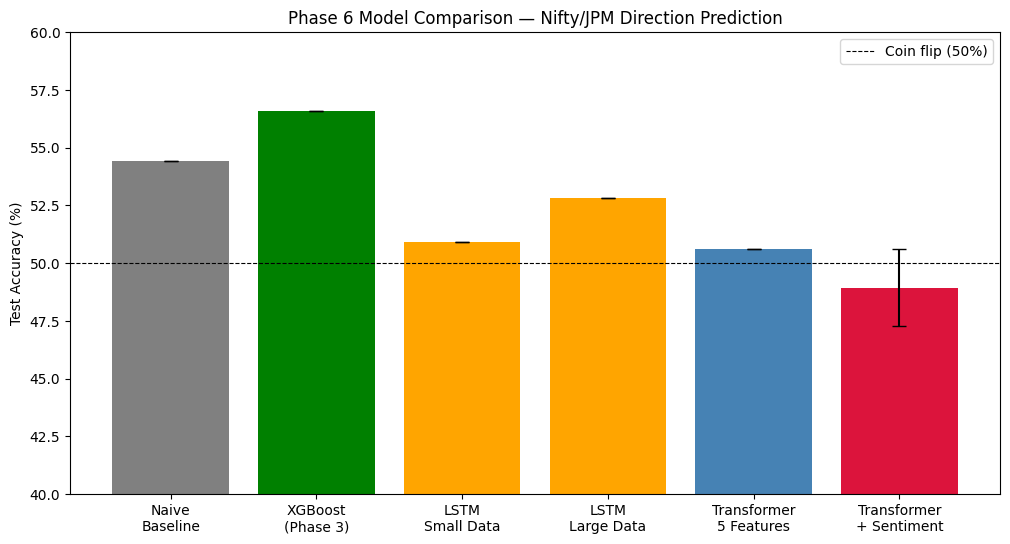

In [58]:
models = ['Naive\nBaseline', 'XGBoost\n(Phase 3)', 'LSTM\nSmall Data', 'LSTM\nLarge Data',
          'Transformer\n5 Features', 'Transformer\n+ Sentiment']
accuracies = [54.4, 56.6, 50.9, 52.8, 50.6, 48.94]
errors = [0, 0, 0, 0, 0, 1.68]  # only the 6th has repeated-run std

plt.figure(figsize=(12,6))
bars = plt.bar(models, accuracies, yerr=errors, capsize=5,
                color=['gray', 'green', 'orange', 'orange', 'steelblue', 'crimson'])
plt.axhline(y=50, color='black', linestyle='--', linewidth=0.8, label='Coin flip (50%)')
plt.ylabel('Test Accuracy (%)')
plt.title('Phase 6 Model Comparison — Nifty/JPM Direction Prediction')
plt.legend()
plt.ylim(40, 60)
plt.show()

**## 13. Visualization: Price & Prediction Accuracy Overlay**

In [59]:
print(len(x))
split = int(0.8 * len(x))
lookback = 20
test_start_idx = split + lookback
test_end_idx = split + lookback + len(x_test) - 1
print(test_start_idx, test_end_idx)

3732
3005 3751


In [60]:
print(test_end_idx - test_start_idx + 1)
print(len(x_test))

747
747


In [61]:
print(jpmc_with_sentiment.columns.tolist())

['returns', 'Volume Ratio', 'Rolling Returns', 'RSI', 'target', 'SP500 Returns', 'weighted_sentiment']


In [62]:
test_dates = jpmc.index[test_start_idx : test_end_idx + 1]
actual_prices = jpmc['Close'].values[test_start_idx : test_end_idx + 1]
print(len(test_dates), len(actual_prices))

747 747


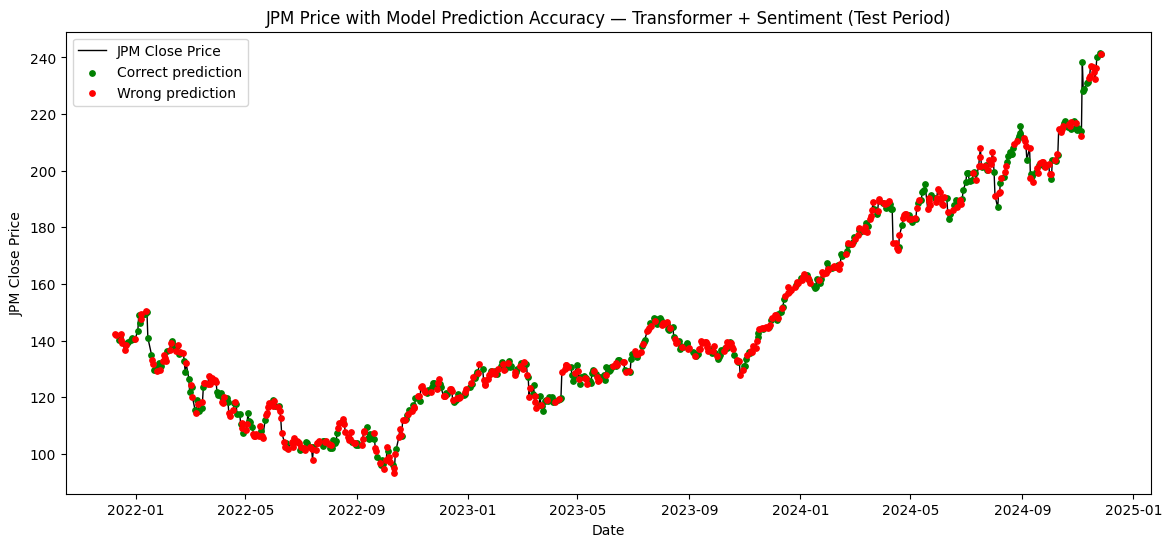

In [63]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test_t)
    y_pred_test_class = (y_pred_test > 0.5).float()

predicted_class = y_pred_test_class.numpy().flatten()
actual_class = y_test_t.numpy().flatten()
correct = (predicted_class == actual_class)

plt.figure(figsize=(14,6))
plt.plot(test_dates, actual_prices, color='black', linewidth=1, label='JPM Close Price')
plt.scatter(test_dates[correct], actual_prices[correct], color='green', s=15, label='Correct prediction', zorder=5)
plt.scatter(test_dates[~correct], actual_prices[~correct], color='red', s=15, label='Wrong prediction', zorder=5)
plt.xlabel('Date')
plt.ylabel('JPM Close Price')
plt.title('JPM Price with Model Prediction Accuracy — Transformer + Sentiment (Test Period)')
plt.legend()
plt.show()

**## 14. Visualization: Confusion Matrix & Directional Bias**

[[145 201]
 [200 201]]


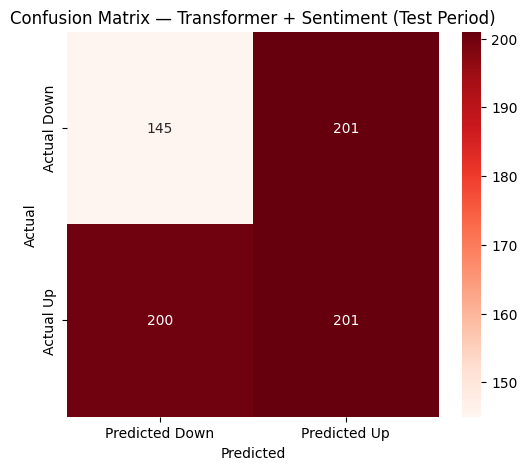

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(actual_class, predicted_class)
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actual Down', 'Actual Up'])
plt.title('Confusion Matrix — Transformer + Sentiment (Test Period)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**## 15. Conclusion & Key Findings**

After running NLP & Transformer model on the 6 featured dataset of S&P500 and JPMC data along with the JPMC's sentiment score 5 times over for weight-initialization randomness, reporting mean ± std instead of single-run numbers. We find that mean test accuracy 48.94% ± 1.68% (range 46.3%-51.4%).